# Corporate AI Investments & Market Impact Analysis
### Quantifying Stock Price Sensitivity to R&D, Revenues, and Strategic Milestones

## **Objective:** Analyze how corporate AI investments (R&D and product revenue) and major milestone events drive stock price impacts for top tech firms (OpenAI, Google, Meta).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\Dell\Data-Science-projects\ai_financial_market_daily_realistic_synthetic.csv")
print("Reading file is successful")

Reading file is successful


In [3]:
df

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09
...,...,...,...,...,...,...,...
10954,2024-12-27,Meta,100.19,103.54,417.68,NaN,-0.66
10955,2024-12-28,Meta,99.12,102.37,411.86,NaN,-0.57
10956,2024-12-29,Meta,98.95,103.11,415.54,NaN,-0.52
10957,2024-12-30,Meta,100.74,103.21,416.03,NaN,0.22


In [4]:
df['Date'] = pd.to_datetime(df['Date'])

df['Event'] = df['Event'].fillna('None')

df['Is_Event_Day'] = df['Event'].apply(lambda x: 'Event' if x != 'None' else 'Baseline')

print("--- DataFrame Info After Cleaning ---")
df.info()

--- DataFrame Info After Cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 10959 non-null  datetime64[ns]
 1   Company              10959 non-null  object        
 2   R&D_Spending_USD_Mn  10959 non-null  float64       
 3   AI_Revenue_USD_Mn    10959 non-null  float64       
 4   AI_Revenue_Growth_%  10959 non-null  float64       
 5   Event                10959 non-null  object        
 6   Stock_Impact_%       10959 non-null  float64       
 7   Is_Event_Day         10959 non-null  object        
dtypes: datetime64[ns](1), float64(4), object(3)
memory usage: 685.1+ KB


In [5]:
df['RD_Efficiency_Ratio'] = df['AI_Revenue_USD_Mn'] / (df['R&D_Spending_USD_Mn'] + 1e-5)

df = df.sort_values(by=['Company', 'Date'])
df['Cumulative_Stock_Impact'] = df.groupby('Company')['Stock_Impact_%'].cumsum()

df[['Date', 'Company', 'RD_Efficiency_Ratio', 'Cumulative_Stock_Impact']].tail(10)

,Date,Company,RD_Efficiency_Ratio,Cumulative_Stock_Impact
3643,2024-12-22,OpenAI,0.484817,148.58
3644,2024-12-23,OpenAI,0.621587,148.57
3645,2024-12-24,OpenAI,0.734925,149.02
3646,2024-12-25,OpenAI,0.733424,148.63
3647,2024-12-26,OpenAI,0.457962,147.74
3648,2024-12-27,OpenAI,0.468190,148.67
3649,2024-12-28,OpenAI,0.550155,148.42
3650,2024-12-29,OpenAI,0.595419,148.89
3651,2024-12-30,OpenAI,0.609073,149.58
3652,2024-12-31,OpenAI,0.480468,148.71


In [6]:
df['Company'].unique()

array(['Google', 'Meta', 'OpenAI'], dtype=object)

In [7]:
df['Year'] = pd.to_datetime(df['Date']).dt.year
df.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Is_Event_Day,RD_Efficiency_Ratio,Cumulative_Stock_Impact,Year
3653,2015-01-01,Google,79.89,30.19,0.64,None,-0.02,Baseline,0.377895,-0.02,2015
3654,2015-01-02,Google,78.99,30.44,1.47,None,-0.98,Baseline,0.385365,-1.00,2015
3655,2015-01-03,Google,79.20,30.46,1.53,None,0.78,Baseline,0.384596,-0.22,2015
3656,2015-01-04,Google,79.59,30.55,1.82,None,-0.41,Baseline,0.383842,-0.63,2015
3657,2015-01-05,Google,81.50,30.59,1.97,None,-0.78,Baseline,0.375337,-1.41,2015


## ==========================================
## EXPLORATORY DATA ANALYSIS
## ==========================================

### Financial Breakdown: Cumulative Corporate R&D Spending (2015–2024)

In [8]:
rd_summary = df.groupby('Company')['R&D_Spending_USD_Mn'].sum().reset_index()

rd_summary.columns = ['Company', 'Total_R&D_Spending_USD_Mn']

rd_summary = rd_summary.sort_values(by='Total_R&D_Spending_USD_Mn', ascending=False)

rd_summary['Total_R&D_Spending_USD_Mn'] = rd_summary['Total_R&D_Spending_USD_Mn'].map('${:,.2f} Mn'.format)
rd_summary

,Company,Total_R&D_Spending_USD_Mn
0,Google,"$423,341.14 Mn"
1,Meta,"$264,533.07 Mn"
2,OpenAI,"$26,482.77 Mn"


### Visualizing Investment: Total R&D Expenditure Comparison

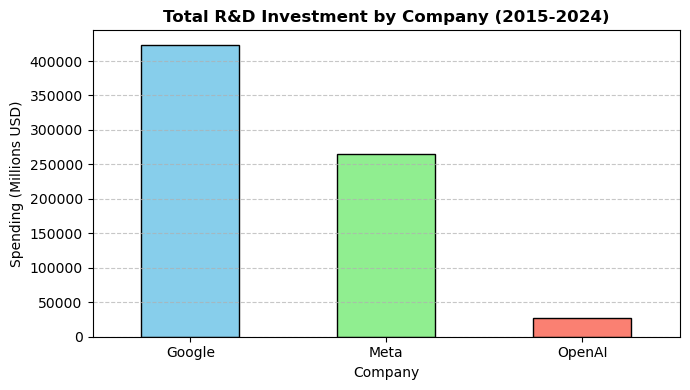

In [9]:
rd_total = df.groupby('Company')['R&D_Spending_USD_Mn'].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
rd_total.plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon'], edgecolor='black')

plt.title('Total R&D Investment by Company (2015-2024)', fontsize=12, fontweight='bold')
plt.xlabel('Company', fontsize=10)
plt.ylabel('Spending (Millions USD)', fontsize=10)
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 

plt.tight_layout()
plt.show()

### Revenue Generation: Total AI Revenue Earned by Company (2015–2024)

In [10]:
revenue_total = df.groupby('Company')['AI_Revenue_USD_Mn'].sum().sort_values(ascending=False)

revenue_summary = revenue_total.reset_index()
revenue_summary.columns = ['Company', 'Total_AI_Revenue_USD_Mn']
revenue_summary['Total_AI_Revenue_USD_Mn'] = revenue_summary['Total_AI_Revenue_USD_Mn'].map('${:,.2f} Mn'.format)

revenue_summary

,Company,Total_AI_Revenue_USD_Mn
0,Google,"$284,498.38 Mn"
1,Meta,"$189,621.82 Mn"
2,OpenAI,"$9,462.89 Mn"


### Illustration of revenues of companies

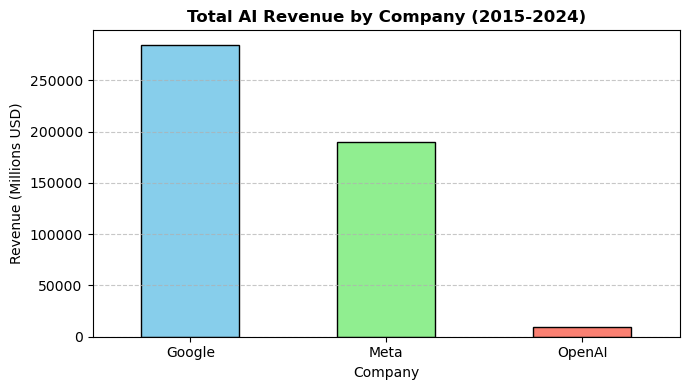

In [11]:
revenue_total = df.groupby('Company')['AI_Revenue_USD_Mn'].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
revenue_total.plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon'], edgecolor='black')

plt.title('Total AI Revenue by Company (2015-2024)', fontsize=12, fontweight='bold')
plt.xlabel('Company', fontsize=10)
plt.ylabel('Revenue (Millions USD)', fontsize=10)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Chronological Analysis: Average Annual Stock Impact by Company (2015–2024)

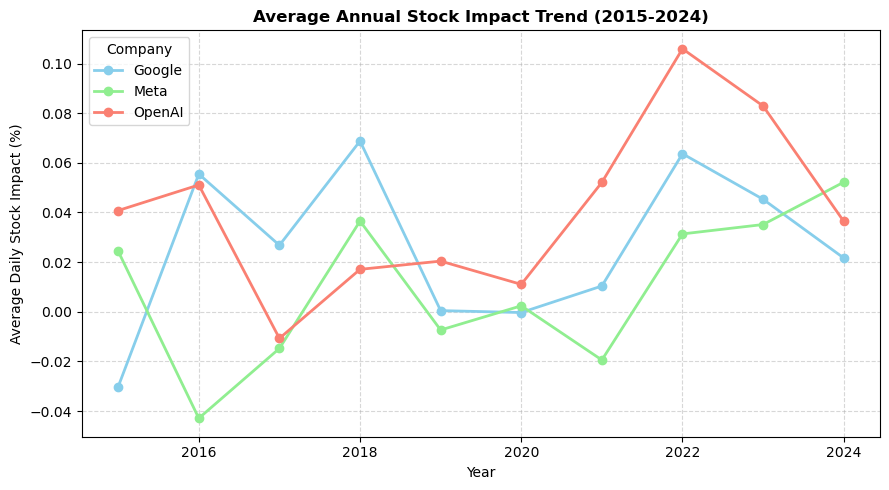

In [12]:
yearly_trend = df.groupby(['Year', 'Company'])['Stock_Impact_%'].mean().unstack()

plt.figure(figsize=(9, 5))
yearly_trend.plot(kind='line', marker='o', linewidth=2, ax=plt.gca(), color=['skyblue', 'lightgreen', 'salmon'])

plt.title('Average Annual Stock Impact Trend (2015-2024)', fontsize=12, fontweight='bold')
plt.xlabel('Year', fontsize=10)
plt.ylabel('Average Daily Stock Impact (%)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Company')

plt.tight_layout()
plt.show()

### Data Segmentation: Isolating Corporate Profiles for Granular Analysis

In [13]:
data_OpenAI = df[df['Company'] == 'OpenAI']

In [14]:
data_OpenAI

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Is_Event_Day,RD_Efficiency_Ratio,Cumulative_Stock_Impact,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,None,-0.36,Baseline,0.106419,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,None,0.41,Baseline,0.334565,0.05,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,None,0.23,Baseline,0.135555,0.28,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,None,0.93,Baseline,0.174312,1.21,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,None,-0.09,Baseline,0.435293,1.12,2015
...,...,...,...,...,...,...,...,...,...,...,...
3648,2024-12-27,OpenAI,10.06,4.71,370.69,None,0.93,Baseline,0.468190,148.67,2024
3649,2024-12-28,OpenAI,9.67,5.32,432.15,None,-0.25,Baseline,0.550155,148.42,2024
3650,2024-12-29,OpenAI,9.17,5.46,445.74,None,0.47,Baseline,0.595419,148.89,2024
3651,2024-12-30,OpenAI,10.36,6.31,530.88,None,0.69,Baseline,0.609073,149.58,2024


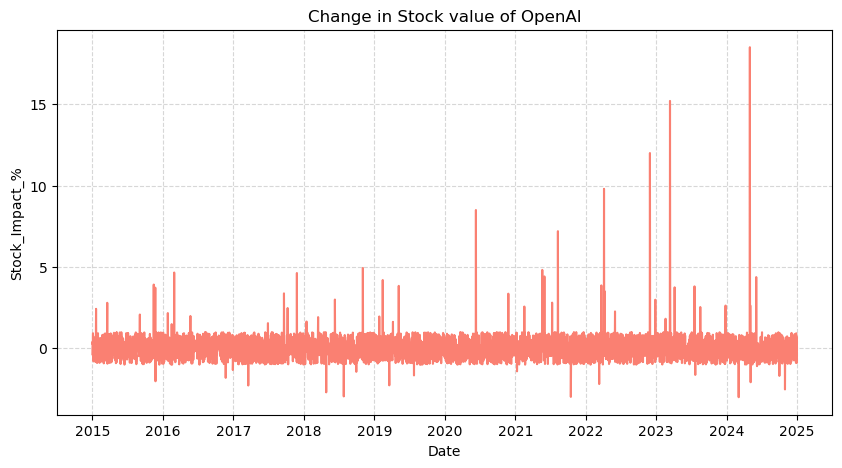

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(data_OpenAI['Date'], data_OpenAI['Stock_Impact_%'], color='salmon')
plt.title("Change in Stock value of OpenAI")
plt.xlabel("Date")
plt.ylabel("Stock_Impact_%")
plt.grid(True, linestyle='--', alpha=0.5) 
plt.show()

In [16]:
data_Google = df[df['Company'] == 'Google']

In [17]:
data_Google

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Is_Event_Day,RD_Efficiency_Ratio,Cumulative_Stock_Impact,Year
3653,2015-01-01,Google,79.89,30.19,0.64,None,-0.02,Baseline,0.377895,-0.02,2015
3654,2015-01-02,Google,78.99,30.44,1.47,None,-0.98,Baseline,0.385365,-1.00,2015
3655,2015-01-03,Google,79.20,30.46,1.53,None,0.78,Baseline,0.384596,-0.22,2015
3656,2015-01-04,Google,79.59,30.55,1.82,None,-0.41,Baseline,0.383842,-0.63,2015
3657,2015-01-05,Google,81.50,30.59,1.97,None,-0.78,Baseline,0.375337,-1.41,2015
...,...,...,...,...,...,...,...,...,...,...,...
7301,2024-12-27,Google,162.16,155.36,417.88,None,-0.46,Baseline,0.958066,96.57,2024
7302,2024-12-28,Google,159.69,154.47,414.89,None,-0.48,Baseline,0.967312,96.09,2024
7303,2024-12-29,Google,161.69,154.59,415.31,None,0.72,Baseline,0.956089,96.81,2024
7304,2024-12-30,Google,158.48,155.05,416.84,None,-0.17,Baseline,0.978357,96.64,2024


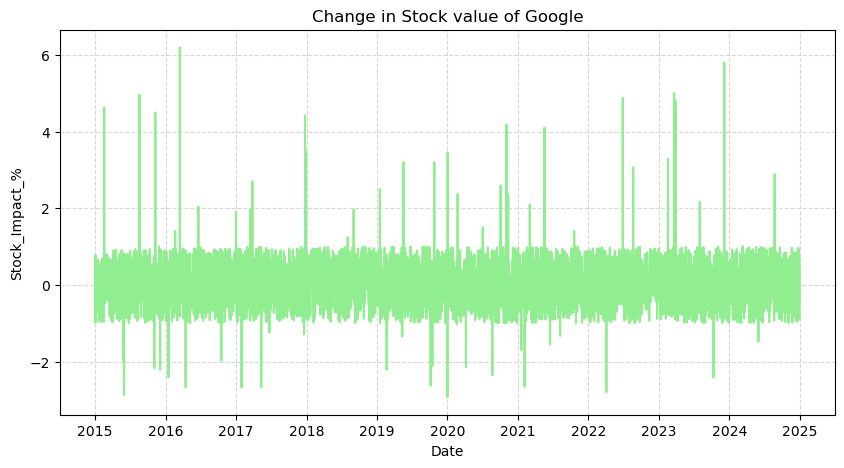

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(data_Google['Date'], data_Google['Stock_Impact_%'], color='lightgreen')
plt.title("Change in Stock value of Google")
plt.xlabel("Date")
plt.ylabel("Stock_Impact_%")
plt.grid(True, linestyle='--', alpha=0.5) 
plt.show()

In [19]:
data_Meta = df[df['Company'] == 'Meta']

In [20]:
data_Meta

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Is_Event_Day,RD_Efficiency_Ratio,Cumulative_Stock_Impact,Year
7306,2015-01-01,Meta,50.39,18.95,-5.23,None,-0.42,Baseline,0.376067,-0.42,2015
7307,2015-01-02,Meta,49.80,19.77,-1.16,None,0.63,Baseline,0.396988,0.21,2015
7308,2015-01-03,Meta,49.09,19.96,-0.21,None,0.73,Baseline,0.406600,0.94,2015
7309,2015-01-04,Meta,50.66,20.48,2.38,None,-0.26,Baseline,0.404264,0.68,2015
7310,2015-01-05,Meta,51.36,19.84,-0.80,None,-0.37,Baseline,0.386293,0.31,2015
...,...,...,...,...,...,...,...,...,...,...,...
10954,2024-12-27,Meta,100.19,103.54,417.68,None,-0.66,Baseline,1.033436,36.69,2024
10955,2024-12-28,Meta,99.12,102.37,411.86,None,-0.57,Baseline,1.032788,36.12,2024
10956,2024-12-29,Meta,98.95,103.11,415.54,None,-0.52,Baseline,1.042041,35.60,2024
10957,2024-12-30,Meta,100.74,103.21,416.03,None,0.22,Baseline,1.024518,35.82,2024


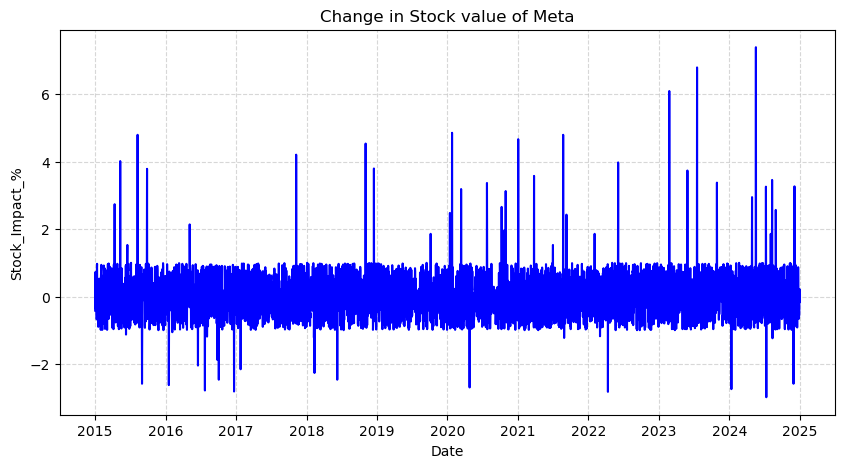

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(data_Meta['Date'], data_Meta['Stock_Impact_%'], color='blue')
plt.title("Change in Stock value of Meta")
plt.xlabel("Date")
plt.ylabel("Stock_Impact_%")
plt.grid(True, linestyle='--', alpha=0.5) 
plt.show()

### Comparative Performance: Average AI Revenue Growth Rate by Company

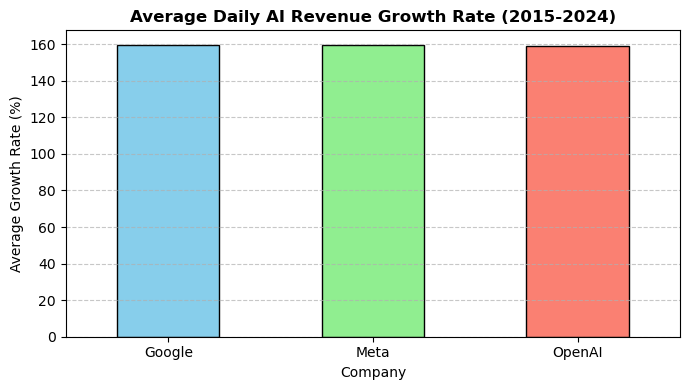

,Company,Average_Growth_Rate_%
0,Google,159.60%
1,Meta,159.54%
2,OpenAI,159.04%


In [22]:
growth_avg = df.groupby('Company')['AI_Revenue_Growth_%'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
growth_avg.plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon'], edgecolor='black')

plt.title('Average Daily AI Revenue Growth Rate (2015-2024)', fontsize=12, fontweight='bold')
plt.xlabel('Company', fontsize=10)
plt.ylabel('Average Growth Rate (%)', fontsize=10)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

growth_summary = growth_avg.reset_index()
growth_summary.columns = ['Company', 'Average_Growth_Rate_%']
growth_summary['Average_Growth_Rate_%'] = growth_summary['Average_Growth_Rate_%'].map('{:.2f}%'.format)
growth_summary

### Market Dynamics: Feature Correlation Matrix Heatmap

In [23]:
df.corr(numeric_only = True)

,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Stock_Impact_%,RD_Efficiency_Ratio,Cumulative_Stock_Impact,Year
R&D_Spending_USD_Mn,1.000000,0.935030,0.291245,-0.004628,0.755657,-0.081353,0.297701
AI_Revenue_USD_Mn,0.935030,1.000000,0.530128,-0.000017,0.874590,0.064725,0.526478
AI_Revenue_Growth_%,0.291245,0.530128,1.000000,0.020937,0.730596,0.652881,0.952199
Stock_Impact_%,-0.004628,-0.000017,0.020937,1.000000,0.005706,0.030284,0.016525
RD_Efficiency_Ratio,0.755657,0.874590,0.730596,0.005706,1.000000,0.096976,0.701748
Cumulative_Stock_Impact,-0.081353,0.064725,0.652881,0.030284,0.096976,1.000000,0.644192
Year,0.297701,0.526478,0.952199,0.016525,0.701748,0.644192,1.000000


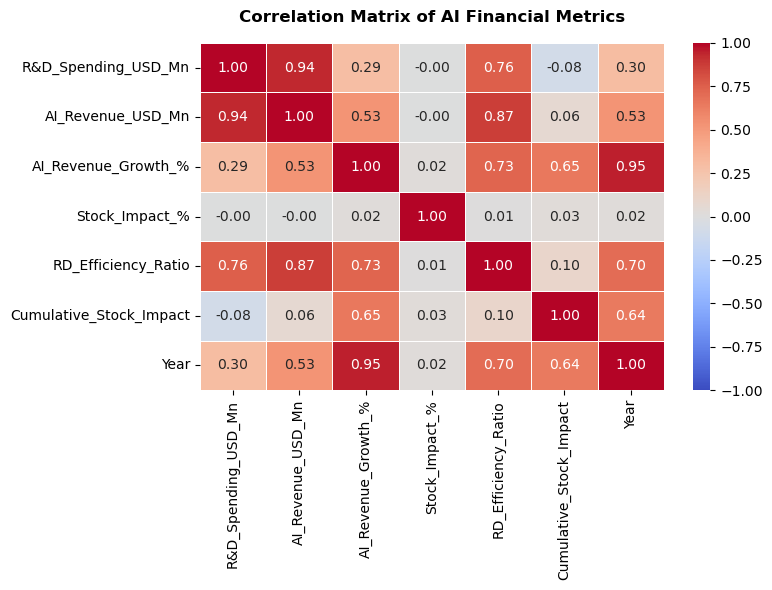

In [24]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Matrix of AI Financial Metrics', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Capital Efficiency: Annual R&D Expenditure vs. AI Revenue (2015–2024)

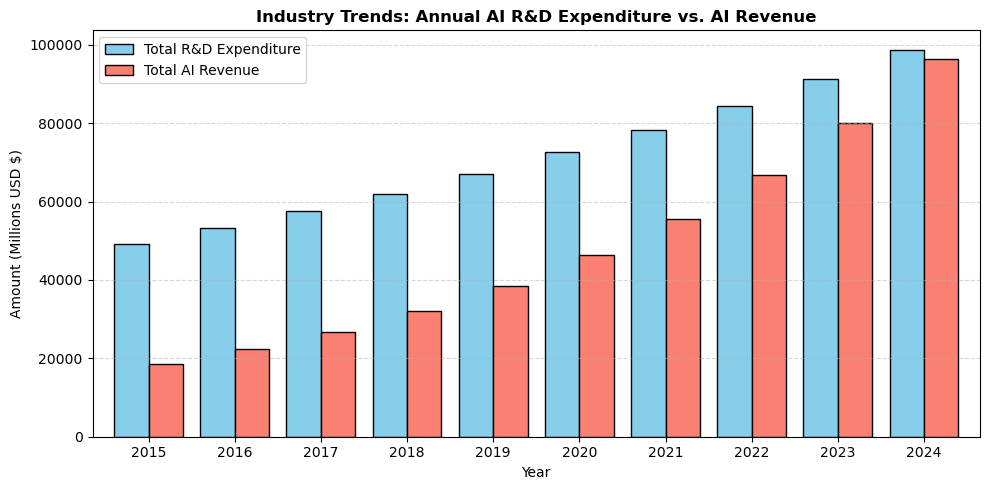

In [25]:
yearly_finance = df.groupby('Year')[['R&D_Spending_USD_Mn', 'AI_Revenue_USD_Mn']].sum()

yearly_finance.columns = ['Total R&D Expenditure', 'Total AI Revenue']

plt.figure(figsize=(10, 5))
yearly_finance.plot(kind='bar', width=0.8, color=['skyblue', 'salmon'], edgecolor='black', ax=plt.gca())

plt.title('Industry Trends: Annual AI R&D Expenditure vs. AI Revenue', fontsize=12, fontweight='bold')
plt.xlabel('Year', fontsize=10)
plt.ylabel('Amount (Millions USD $)', fontsize=10)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

### Portfolio Performance: Annual Index Performance Breakdown by Company

In [26]:
index_summary = df.groupby(['Year', 'Company'])['Stock_Impact_%'].mean().unstack()

index_summary = index_summary.round(2)

index_summary

Company,Google,Meta,OpenAI
Year,,,
2015,-0.03,0.02,0.04
2016,0.06,-0.04,0.05
2017,0.03,-0.01,-0.01
2018,0.07,0.04,0.02
2019,0.00,-0.01,0.02
2020,-0.00,0.00,0.01
2021,0.01,-0.02,0.05
2022,0.06,0.03,0.11
2023,0.05,0.04,0.08


### Executive Summary & Key Findings

### 1. R&D and Revenue Scaling: Google and Meta maintain massive infrastructure advantages, outspending OpenAI in cumulative R&D by over 10x. This capital investment strongly correlates (0.94) with top-line AI revenue generation.

### 2. Growth Velocity: Despite the scale disparities, all three entities maintain a near-identical average daily AI revenue growth rate (~159%). This indicates aggressive, sector-wide secular tailwinds rather than winner-take-all consolidation.

### 3. Market Volatility: Daily stock impacts show virtually zero linear correlation with smooth, daily fundamental operational metrics. Stock adjustments happen via market events, milestones, and news shocks rather than standard reporting.